# Receiver Operating Characteristic (ROC)

A ROC curve shows the ability of a probabilitic forecast of a binary event (e.g., chance of rainfall) to discriminate between events and non-events. It plots the hit rate or probability of detection (POD) against the false alarm rate or probability of false detection (POFD) using a set of increasing probability thresholds (e.g., 0.1, 0.2, 0.3, ...) that convert the probabilistic forecast into a binary forecast.

The area under the ROC curve is often used as a measure of discrimination ability. ROC is insensitive to forecast bias so should be used together with reliablity or some other metric which is measures bias.

In [1]:
from scores.categorical import probability_of_detection, probability_of_false_detection
from scores.plotdata import roc
from scores.probability import roc_auc
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from scipy.stats import beta, binom

Imagine we have a sequence of binary forecasts and a sequence of binary observations, where 1 indicates a forecast or observed event and 0 indicates a forecast or observed non-event.

In [2]:
fcst = xr.DataArray([1, 0, 1, 0, 1])
obs = xr.DataArray([1, 0, 0, 1, 1])

We can then use `scores` to calculate the POD ($\frac{H}{H + M}$) and POFD ($\frac{F}{C + F}$), where $H, M, F, C$ are the number of hits, misses, false alarms, and correct negatives respectively.

In [3]:
probability_of_detection(fcst, obs)

<xarray.DataArray ()> Size: 8B
array(0.66666667)

In [4]:
probability_of_false_detection(fcst, obs)

<xarray.DataArray ()> Size: 8B
array(0.5)

Now suppose that we have a forecast that is the probability of rain occuring, and corresponding observations where 1 means it rained, and 0 means that it didn't rain. We generate some synthetic forecasts using a Beta distribution and generate some corresponding observations.

In [5]:
fcst = beta.rvs(2, 1, size=1000)
obs = binom.rvs(1, fcst)
fcst = xr.DataArray(data=fcst, dims="time", coords={"time": np.arange(0, 1000)})
obs = xr.DataArray(data=obs, dims="time", coords={"time": np.arange(0, 1000)})

Now calculate the ROC curve.

In [6]:
roc_data = roc(fcst, obs)
roc_data

<xarray.Dataset> Size: 24kB
Dimensions:    (threshold: 1002)
Coordinates:
  * threshold  (threshold) float64 8kB 0.0 0.02971 0.05 ... 0.9991 0.9997 inf
Data variables:
    POD        (threshold) float64 8kB 1.0 1.0 1.0 1.0 ... 0.003044 0.001522 0.0
    POFD       (threshold) float64 8kB 1.0 1.0 0.9971 0.9942 ... 0.0 0.0 0.0 0.0
    AUC        float64 8B 0.8151

The thresholds were generated automatically using all of the unique forecast values The output shows the POD and POFD for each threshold. We also calculated the AUC which is the area under the ROC curve, which we will discuss shortly. Let's now plot the ROC curve.

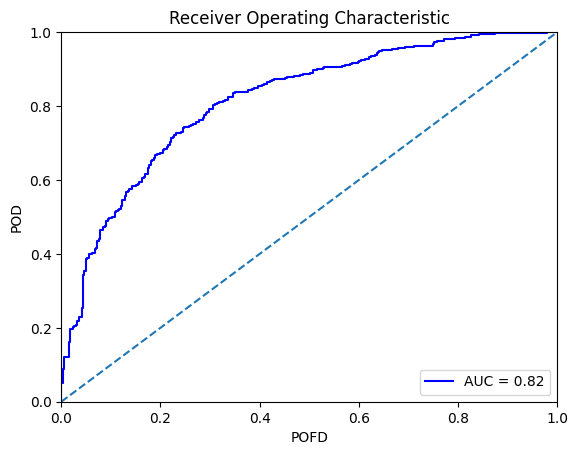

In [7]:
plt.title("Receiver Operating Characteristic")
plt.plot(roc_data.POFD, roc_data.POD, "b", label="AUC = %0.2f" % roc_data.AUC.item())
plt.legend(loc="lower right")
plt.plot([0, 1], [0, 1], "--")
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel("POD")
plt.xlabel("POFD")
plt.show()

- A perfect ROC curve would go from the lower left corner, up to the top left corner, and across to the top right corner.
- If the curve follows the dotted line, it means the forecast has no discrimination ability. This synthetic forecast clearly does have discrimination ability.
- The AUC is the area under the curve. 1 is the maximum value that can be achieved. If we picked a random forecast value from our dataset where the event occurred, and a random forecast value when the event did not occur, the AUC tells us the probability that the former forecast value will be greater than the latter.

### Calculating ROC AUC more efficiently
If you don't want to produce ROC curves and instead would like to only calculate the AUC, you can instead call `scores.probability.roc_auc` which is significantly more computationally efficient

In [10]:
# Uncomment the line below to learn more
# help(roc_auc)

In [11]:
roc_auc(fcst, obs)

<xarray.DataArray ()> Size: 8B
array(0.81510621)

### Cautionary notes
- ROC or AUC is not a suitable overall performance measure for a probabilistic classifier as it is not a proper scoring rule and is ignorant of calibration (Hand 2009; Hand and Anagnostopoulos 2013, 2023). It is however, a useful tool for understanding potential predictive performance subject to recalibration.
- Non-concave ROC curves like the synthetic example above have several problems (Pesce et al. 2010; Geniting and Vogel 2022). To get around these problems, you can apply isotonic regression to the forecast data before you calculate the ROC curves (Fawcett and Niculescu-Mizil 2007).
- Results may be misleading if two ROC curves cross (Hand 2009).

## Things to try next
- Supply a list or 1D array of thresholds into the `thresholds` arg. This can be useful in the case when there are so many unique values that it becomes computationally slow.

### References
Fawcett, T. and Niculescu-Mizil, A., 2007. PAV and the ROC convex hull. Machine Learning, 68, pp.97-106.

Gneiting, T. and Vogel, P., 2022. Receiver operating characteristic (ROC) curves: equivalences, beta model, and minimum distance estimation. Machine learning, 111(6), pp.2147-2159.

Hand, D.J., 2009. Measuring classifier performance: a coherent alternative to the area under the ROC curve. Machine learning, 77(1), pp.103-123.

Hand, D.J. and Anagnostopoulos, C., 2013. When is the area under the receiver operating characteristic curve an appropriate measure of classifier performance?. Pattern Recognition Letters, 34(5), pp.492-495.

Hand, D.J. and Anagnostopoulos, C., 2023. Notes on the H-measure of classifier performance. Advances in Data Analysis and Classification, 17(1), pp.109-124.

Pesce, L.L., Metz, C.E. and Berbaum, K.S., 2010. On the convexity of ROC curves estimated from radiological test results. Academic radiology, 17(8), pp.960-968.